# MTL Embeddings Visualization

This notebook visualizes the embeddings from the trained MTL (Multi-Task Learning) model using PCA, t-SNE, and interactive plots.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Set styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Load CSV Embedding Data

In [6]:
# Load embedding CSV
csv_path = "MLC/visualize_mtl_20260227_073453/embeddings.csv"  # Change this to your CSV path
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} embedding points")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)

Loaded 1824 embedding points

DataFrame shape: (1824, 8)

Columns: ['method', 'x', 'y', 'liquid_label', 'liquid_name', 'bottle_label', 'bottle_name', 'path']

First few rows:
  method          x          y  liquid_label   liquid_name  bottle_label  \
0    pca  14.662847 -22.528560             7   liq-salt002             1   
1    pca   8.101129   8.892966            17   liq-vinegar             3   
2    pca   7.467807  13.180716            12  liq-sugar005             2   
3    pca   1.024066 -30.072609             7   liq-salt002             0   
4    pca -20.303522 -11.977127            16     liq-syrup             0   

  bottle_name                                               path  
0     glass02  /mnt/iusers01/fatpou01/compsci01/k09562zs/scra...  
1       pet02  /mnt/iusers01/fatpou01/compsci01/k09562zs/scra...  
2       pet01  /mnt/iusers01/fatpou01/compsci01/k09562zs/scra...  
3     glass01  /mnt/iusers01/fatpou01/compsci01/k09562zs/scra...  
4     glass01  /mnt/iusers01/fatp

## 3. Explore Embedding Structure

In [7]:
# Separate PCA and t-SNE data
pca_data = df[df['method'] == 'pca'].copy()
tsne_data = df[df['method'] == 'tsne'].copy()

print(f"PCA samples: {len(pca_data)}")
print(f"t-SNE samples: {len(tsne_data)}")

# Unique labels
print(f"\n=== Liquid Classes ===")
print(f"Unique liquid classes: {pca_data['liquid_name'].nunique()}")
print(pca_data['liquid_name'].value_counts().sort_index())

print(f"\n=== Bottle Types ===")
print(f"Unique bottle types: {pca_data['bottle_name'].nunique()}")
print(pca_data['bottle_name'].value_counts())

PCA samples: 912
t-SNE samples: 912

=== Liquid Classes ===
Unique liquid classes: 19
liquid_name
liq-dishwash       48
liq-ethanol        48
liq-grape_juice    48
liq-handwash       48
liq-milk           48
liq-milkshake      48
liq-oil            48
liq-salt002        48
liq-salt004        48
liq-salt006        48
liq-salt008        48
liq-soy_sauce      48
liq-sugar005       48
liq-sugar010       48
liq-sugar015       48
liq-sugar020       48
liq-syrup          48
liq-vinegar        48
liq-water          48
Name: count, dtype: int64

=== Bottle Types ===
Unique bottle types: 4
bottle_name
glass02    228
pet02      228
pet01      228
glass01    228
Name: count, dtype: int64


## 4. Visualization: PCA Results

In [ ]:
# PCA - Liquid Classification
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Liquid
ax = axes[0]
for liquid_name in pca_data['liquid_name'].unique():
    mask = pca_data['liquid_name'] == liquid_name
    ax.scatter(pca_data[mask]['x'], pca_data[mask]['y'], s=15, alpha=0.6, label=liquid_name)
ax.set_title('PCA - Liquid Classes', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Bottle
ax = axes[1]
for bottle_name in pca_data['bottle_name'].unique():
    mask = pca_data['bottle_name'] == bottle_name
    ax.scatter(pca_data[mask]['x'], pca_data[mask]['y'], s=50, alpha=0.7, label=bottle_name, marker='o')
ax.set_title('PCA - Bottle Types', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Visualization: t-SNE Results

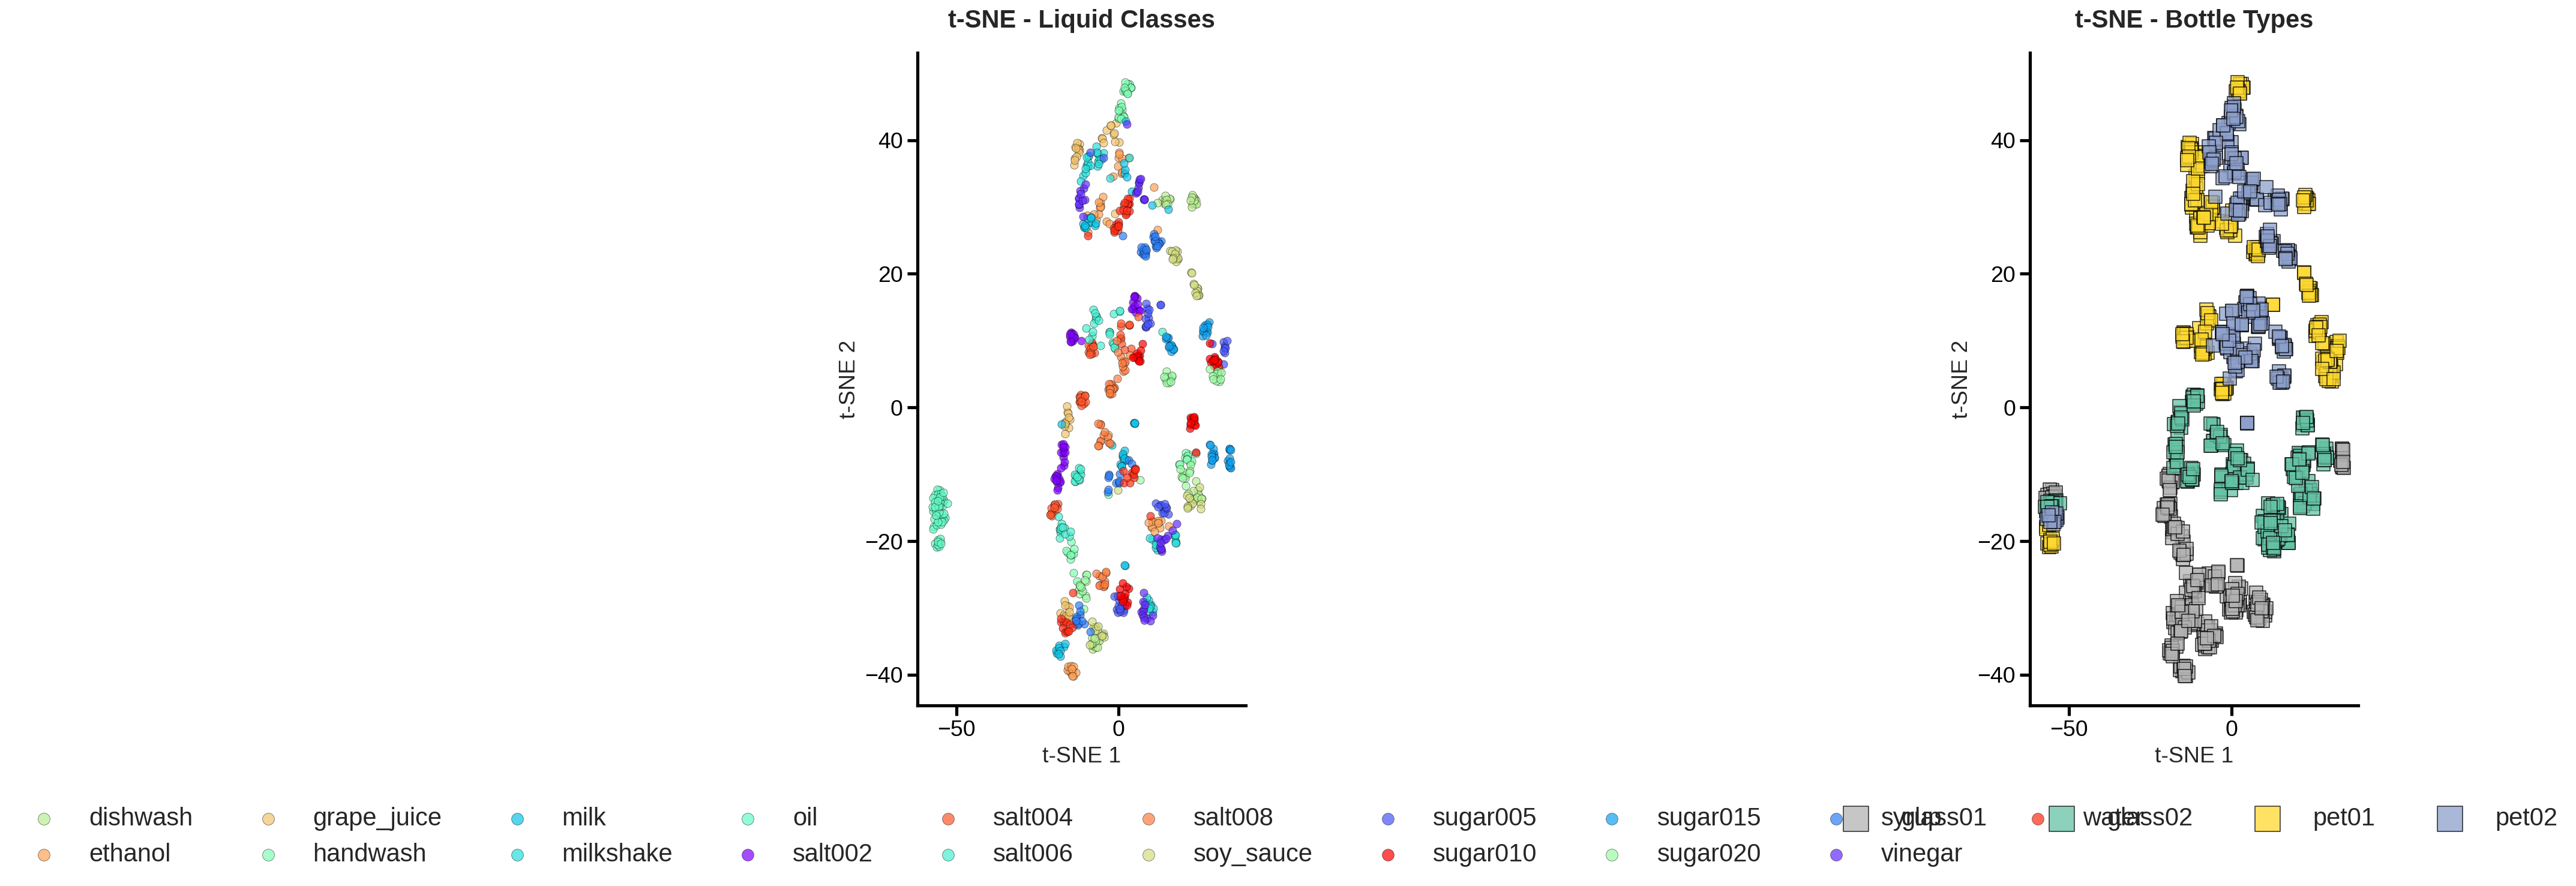

In [27]:
# t-SNE - Liquid Classification
# Set high DPI for better quality
plt.rcParams['figure.dpi'] = 100
fig, axes = plt.subplots(1, 2, figsize=(24, 10), dpi=150)

# Get rainbow colors
colors = plt.cm.rainbow(np.linspace(0, 1, tsne_data['liquid_name'].nunique()))
color_map = {name: colors[i] for i, name in enumerate(tsne_data['liquid_name'].unique())}

# Liquid
ax = axes[0]
for liquid_name in sorted(tsne_data['liquid_name'].unique()):
    mask = tsne_data['liquid_name'] == liquid_name
    display_label = liquid_name.replace('liq-', '')
    ax.scatter(tsne_data[mask]['x'], tsne_data[mask]['y'], s=40, alpha=0.7, 
              label=display_label, color=color_map[liquid_name], edgecolors='black', linewidth=0.3)
ax.set_title('t-SNE - Liquid Classes', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('t-SNE 1', fontsize=18)
ax.set_ylabel('t-SNE 2', fontsize=18)
ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_linewidth(2.5)
ax.spines['bottom'].set_linewidth(2.5)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.tick_params(axis='both', which='major', labelsize=18, length=8, width=2.5, colors='black')
ax.grid(False)
ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center', fontsize=20, ncol=10, frameon=False, markerscale=1.5)

# Bottle
bottle_colors = plt.cm.Set2(np.linspace(0, 1, tsne_data['bottle_name'].nunique()))
bottle_color_map = {name: bottle_colors[i] for i, name in enumerate(tsne_data['bottle_name'].unique())}

ax = axes[1]
for bottle_name in sorted(tsne_data['bottle_name'].unique()):
    mask = tsne_data['bottle_name'] == bottle_name
    ax.scatter(tsne_data[mask]['x'], tsne_data[mask]['y'], s=120, alpha=0.75, 
              label=bottle_name, marker='s', color=bottle_color_map[bottle_name], edgecolors='black', linewidth=0.8)
ax.set_title('t-SNE - Bottle Types', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('t-SNE 1', fontsize=18)
ax.set_ylabel('t-SNE 2', fontsize=18)   
ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_linewidth(2.5)
ax.spines['bottom'].set_linewidth(2.5)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.tick_params(axis='both', which='major', labelsize=18, length=8, width=2.5, colors='black')
ax.grid(False)
ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center', fontsize=20, ncol=4, frameon=False, markerscale=1.8)

plt.tight_layout()
plt.savefig('tsne_visualization_hq.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Interactive Visualization with Plotly

In [9]:
# Interactive PCA - Liquid
fig1 = px.scatter(
    pca_data,
    x='x', y='y',
    color='liquid_name',
    title='Interactive PCA - Liquid Classes',
    hover_data=['liquid_name', 'bottle_name', 'path'],
    width=900, height=700
)
fig1.update_traces(marker=dict(size=6))
fig1.show()

print("---")

# Interactive PCA - Bottle
fig2 = px.scatter(
    pca_data,
    x='x', y='y',
    color='bottle_name',
    title='Interactive PCA - Bottle Types',
    hover_data=['liquid_name', 'bottle_name'],
    width=900, height=700,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig2.update_traces(marker=dict(size=8))
fig2.show()

---


In [10]:
# Interactive t-SNE - Liquid
fig3 = px.scatter(
    tsne_data,
    x='x', y='y',
    color='liquid_name',
    title='Interactive t-SNE - Liquid Classes',
    hover_data=['liquid_name', 'bottle_name', 'path'],
    width=900, height=700
)
fig3.update_traces(marker=dict(size=6))
fig3.show()

print("---")

# Interactive t-SNE - Bottle
fig4 = px.scatter(
    tsne_data,
    x='x', y='y',
    color='bottle_name',
    title='Interactive t-SNE - Bottle Types',
    hover_data=['liquid_name', 'bottle_name'],
    width=900, height=700,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig4.update_traces(marker=dict(size=8))
fig4.show()

---


## 7. Clustering Analysis Visualization

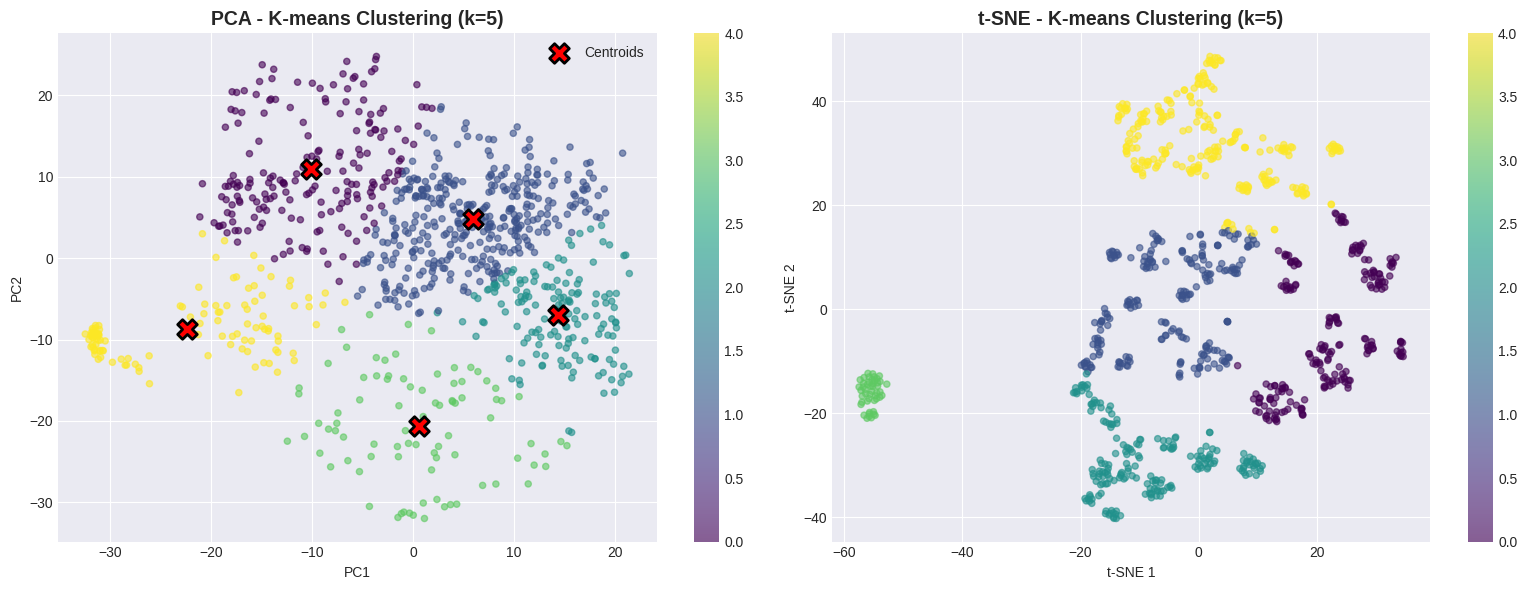


=== Cluster Composition (Liquid) ===

Cluster 0 (192 samples):
liquid_name
liq-sugar005    24
liq-vinegar     24
liq-sugar015    23
Name: count, dtype: int64

Cluster 1 (366 samples):
liquid_name
liq-milk        35
liq-sugar010    32
liq-water       31
Name: count, dtype: int64

Cluster 2 (155 samples):
liquid_name
liq-grape_juice    32
liq-salt002        26
liq-salt006        24
Name: count, dtype: int64

Cluster 3 (86 samples):
liquid_name
liq-salt006    24
liq-salt004    24
liq-salt002    22
Name: count, dtype: int64

Cluster 4 (113 samples):
liquid_name
liq-oil      48
liq-syrup    15
liq-water    12
Name: count, dtype: int64


In [11]:
# K-means clustering on PCA
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
pca_data_copy = pca_data.copy()
pca_data_copy['cluster'] = kmeans.fit_predict(pca_data[['x', 'y']])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA - Clusters
ax = axes[0]
scatter = ax.scatter(pca_data_copy['x'], pca_data_copy['y'], 
                     c=pca_data_copy['cluster'], cmap='viridis', s=20, alpha=0.6)
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
          c='red', s=200, marker='X', edgecolors='black', linewidths=2, label='Centroids')
ax.set_title(f'PCA - K-means Clustering (k={n_clusters})', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.colorbar(scatter, ax=ax)

# t-SNE - Clusters
tsne_data_copy = tsne_data.copy()
tsne_data_copy['cluster'] = kmeans.fit_predict(tsne_data[['x', 'y']])
ax = axes[1]
scatter = ax.scatter(tsne_data_copy['x'], tsne_data_copy['y'], 
                     c=tsne_data_copy['cluster'], cmap='viridis', s=20, alpha=0.6)
ax.set_title(f't-SNE - K-means Clustering (k={n_clusters})', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

# Cluster composition
print("\n=== Cluster Composition (Liquid) ===")
for cluster_id in range(n_clusters):
    cluster_data = pca_data_copy[pca_data_copy['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_data)} samples):")
    print(cluster_data['liquid_name'].value_counts().head(3))

## 8. Summary and Statistics

In [12]:
# Summary statistics
print("="*80)
print("MTL EMBEDDINGS VISUALIZATION SUMMARY")
print("="*80)
print(f"\n📊 Dataset Overview:")
print(f"   Total samples: {len(pca_data)}")
print(f"   Dimensionality reduction methods: PCA, t-SNE")
print(f"   Embedding dimension: 2D")

print(f"\n🧪 Liquid Classification:")
print(f"   Total liquid classes: {pca_data['liquid_name'].nunique()}")
print(f"   Classes: {sorted(pca_data['liquid_name'].unique().tolist())}")
print(f"   Samples per class (avg): {len(pca_data) / pca_data['liquid_name'].nunique():.1f}")

print(f"\n🍾 Bottle Type Classification:")
print(f"   Total bottle types: {pca_data['bottle_name'].nunique()}")
print(f"   Types: {sorted(pca_data['bottle_name'].unique().tolist())}")
print(f"   Samples per type (avg): {len(pca_data) / pca_data['bottle_name'].nunique():.1f}")

print(f"\n📈 Clustering Analysis:")
print(f"   K-means clusters (k): {n_clusters}")
print(f"   Largest cluster size: {pca_data_copy['cluster'].value_counts().max()}")
print(f"   Smallest cluster size: {pca_data_copy['cluster'].value_counts().min()}")

print(f"\n✅ Visualization Complete!")
print("="*80)

MTL EMBEDDINGS VISUALIZATION SUMMARY

📊 Dataset Overview:
   Total samples: 912
   Dimensionality reduction methods: PCA, t-SNE
   Embedding dimension: 2D

🧪 Liquid Classification:
   Total liquid classes: 19
   Classes: ['liq-dishwash', 'liq-ethanol', 'liq-grape_juice', 'liq-handwash', 'liq-milk', 'liq-milkshake', 'liq-oil', 'liq-salt002', 'liq-salt004', 'liq-salt006', 'liq-salt008', 'liq-soy_sauce', 'liq-sugar005', 'liq-sugar010', 'liq-sugar015', 'liq-sugar020', 'liq-syrup', 'liq-vinegar', 'liq-water']
   Samples per class (avg): 48.0

🍾 Bottle Type Classification:
   Total bottle types: 4
   Types: ['glass01', 'glass02', 'pet01', 'pet02']
   Samples per type (avg): 228.0

📈 Clustering Analysis:
   K-means clusters (k): 5
   Largest cluster size: 366
   Smallest cluster size: 86

✅ Visualization Complete!
